In [122]:
import math
from itertools import cycle
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [83]:
load_dir = Path("~/Data")
attributes = pl.read_csv(load_dir / "all_attributes.csv")
trips = pl.read_csv(load_dir / "all_trips.csv")

# replace "unknown" with null in attributes for all columns where "unknown" is a valid value
attributes = attributes.with_columns(
    pl.when(pl.col(col) == "unknown")
    .then(None)
    .otherwise(pl.col(col))
    .alias(col)
    for col in attributes.columns
    if attributes[col].dtype == pl.String
)

attributes.head()

hid,pid,age,hh_size,hh_income,sex,dwelling,ownership,vehicles,disability,education,can_wfh,occupation,race,has_licence,relationship,employment,country,source,year,month,day,rurality,weight
str,str,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,f64
"""ltds24127231""","""ltds2412723104""",3,4,154751,"""male""",null,null,1,null,null,"""n/a""","""n/a""",null,"""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""saturday""","""suburban""",888.083537
"""ltds24057183""","""ltds2405718303""",1,3,null,"""male""",null,null,0,null,null,"""n/a""","""n/a""",null,"""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""saturday""","""suburban""",1389.686246
"""ltds24261191""","""ltds2426119103""",4,3,69654,"""female""",null,null,1,null,null,"""n/a""","""n/a""",null,"""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""wednesday""","""suburban""",573.793877
"""ltds24392111""","""ltds2439211107""",0,7,145236,"""female""",null,null,2,null,null,"""n/a""","""n/a""",null,"""no""","""other""","""student""","""uk""","""ltds""",2024,null,"""tuesday""","""suburban""",490.465951
"""ltds24295273""","""ltds2429527302""",1,2,null,"""female""",null,null,0,null,null,"""n/a""","""n/a""",null,"""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""monday""","""urban""",1394.780525


In [84]:
def group_null_pct(
    df: pl.DataFrame,
    group_cols: Iterable[str],
    ignore: Optional[Iterable[str]] = None,
    return_per_column: bool = False,
    return_overall: bool = True,
) -> pl.DataFrame:
    """
    Compute null percentages per group.
    - return_per_column=True: adds one column per input column with % nulls
    - return_overall=True: adds a single 'overall_null_pct' across all kept columns
    """
    ignore = list(ignore) if ignore else []
    kept_cols = df.select(pl.all().exclude(ignore)).columns
    k = len(kept_cols)
    if k == 0 and return_overall:
        raise ValueError(
            "No columns left after excluding; overall % null is undefined."
        )

    agg_exprs = []

    if return_per_column:
        agg_exprs.append((pl.all().exclude(ignore).is_null().mean() * 100))

    if return_overall:
        total_nulls_expr = pl.fold(
            acc=pl.lit(0),
            function=lambda acc, s: acc + s,
            exprs=[pl.col(c).is_null().sum() for c in kept_cols],
        )
        agg_exprs.append(
            (total_nulls_expr / (pl.len() * pl.lit(k)) * 100).alias(
                "overall_null_pct"
            )
        )

    summary = df.group_by(list(group_cols)).agg(agg_exprs)
    summary = summary.with_columns(
        pl.col(col).list.first()
        for col in summary.columns
        if summary[col].dtype == pl.List
    )
    return summary

In [ ]:
attribute_counts = attributes.group_by("source").agg(n_attributes=pl.len())

null_counts = group_null_pct(
    attributes,
    group_cols=["source"],
    ignore=["hid", "pid", "source"],
    return_per_column=False,
    return_overall=True,
)

trip_counts = (
    trips.join(attributes.select("pid", "source"), on="pid", how="left")
    .group_by("source")
    .agg(n_trips=pl.len())
)

distance_counts = (
    trips.join(attributes.select("pid", "source"), on="pid", how="left")
    .group_by("source")
    .agg(total_distance=pl.col("distance").sum() / 1000000)
)

attributes_summary = (
    attribute_counts.join(
        null_counts.select("source", "overall_null_pct"),
        on="source",
        how="left",
    )
    .join(trip_counts, on="source", how="left")
    .join(distance_counts, on="source", how="left")
    .fill_null(0)
    .rename(
        {
            "n_attributes": "persons",
            "n_trips": "trips",
            "overall_null_pct": "nulls",
            "total_distance": "kms (millions)",
        }
    )
)

total_nulls = sum(
    [
        attributes[col].is_null().sum()
        for col in attributes.head()
        .select(pl.all().exclude("hid", "pid", "source"))
        .columns
    ]
)

# add total row
total_row = pl.DataFrame(
    {
        "source": ["total"],
        "persons": [attributes.height],
        "trips": [trips.height],
        "nulls": [
            total_nulls / (attributes.height * (attributes.width - 3)) * 100
        ],
        "kms (millions)": [
            trips.select(pl.col("distance").sum() / 1000000).item()
        ],
    },
    schema={
        "source": pl.String,
        "persons": pl.UInt32,
        "trips": pl.UInt32,
        "nulls": pl.Float64,
        "kms (millions)": pl.Float64,
    },
)

attributes_summary = pl.concat([attributes_summary, total_row], how="diagonal")

print(attributes_summary)

shape: (7, 5)
┌────────┬─────────┬───────────┬─────────┬────────────────┐
│ source ┆ persons ┆ nulls     ┆ trips   ┆ kms (millions) │
│ ---    ┆ ---     ┆ ---       ┆ ---     ┆ ---            │
│ str    ┆ u32     ┆ f64       ┆ u32     ┆ f64            │
╞════════╪═════════╪═══════════╪═════════╪════════════════╡
│ ltds   ┆ 71734   ┆ 27.171216 ┆ 137900  ┆ 1.394687       │
│ nts    ┆ 1728067 ┆ 13.640509 ┆ 5106905 ┆ 65.155894      │
│ nhts   ┆ 716376  ┆ 15.638422 ┆ 2604832 ┆ 42.055233      │
│ cmap   ┆ 31540   ┆ 0.190839  ┆ 101965  ┆ 0.84082        │
│ vista  ┆ 94821   ┆ 20.107009 ┆ 257557  ┆ 2.451181       │
│ qhts   ┆ 51481   ┆ 24.990172 ┆ 126485  ┆ 1.415566       │
│ total  ┆ 2694019 ┆ 14.81909  ┆ 8461994 ┆ 115.267762     │
└────────┴─────────┴───────────┴─────────┴────────────────┘


/tmp/ipykernel_3731516/1165489785.py:29: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  if dt in pl.NUMERIC_DTYPES and c != on and c not in ignore_cols


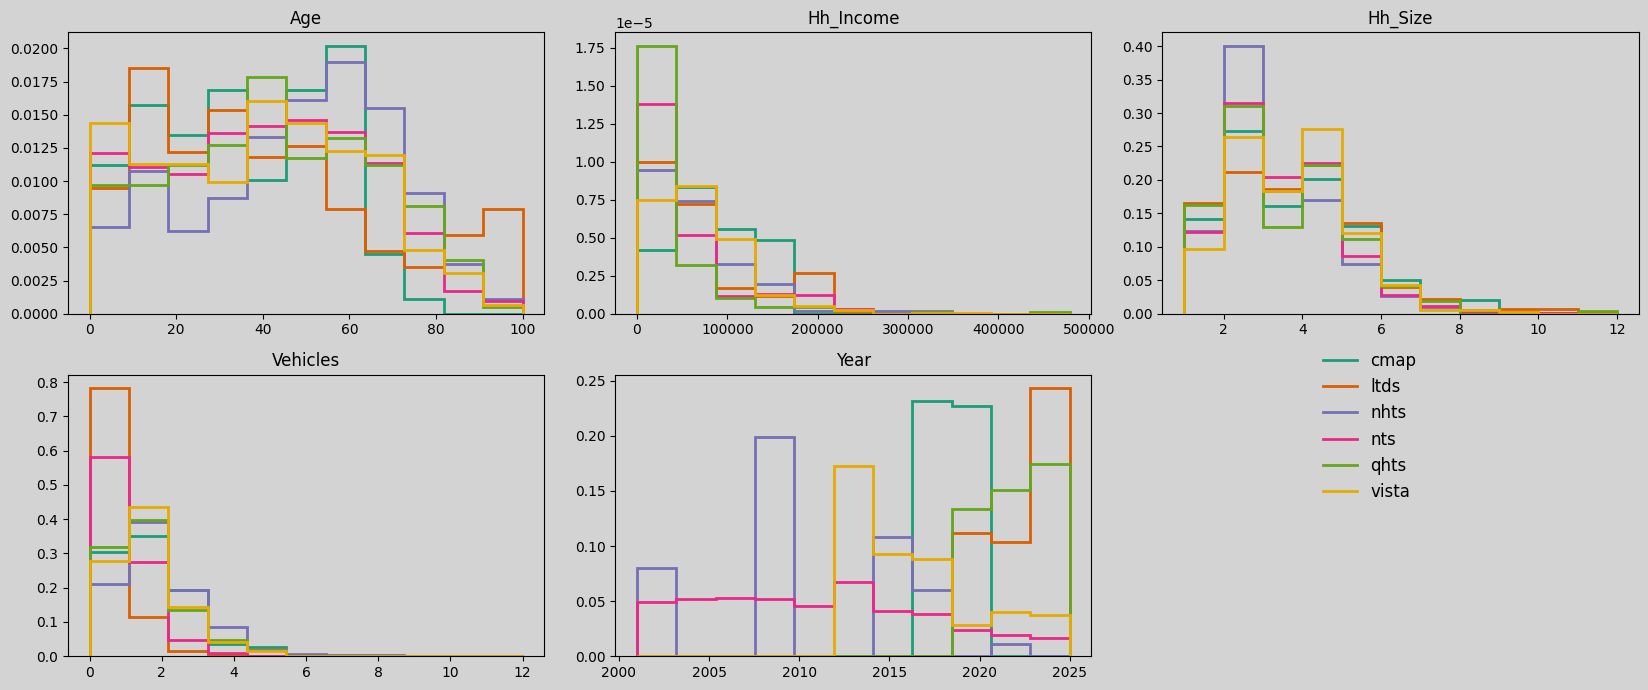

In [129]:
def plot_numeric_hist_grid(
    df: pl.DataFrame,
    on: str = "source",
    n_cols: int = 3,
    max_sample: int = 10_000,
    bins="auto",  # or int (e.g., 30), "fd", "scott", etc.
    density: bool = True,  # normalize so groups are comparable
    cmap_name: str = "tab20",
    linewidth: float = 3,
    fig_bg: str = "lightgray",
    ax_bg: str = "lightgray",
    ignore_cols: list | set | tuple = (),
    min_unique: int = 5,  # skip near-constant numeric columns
    min_group_rows: int = 10,
    # --- long tail handling ---
    tail_handling: str | None = "ignore",  # {"ignore", "clip", None}
    tail_ratio_threshold: float = 4.0,  # larger => more tolerant
    outlier_share_max: float = 0.05,  # larger => more tolerant
    clip_percentiles: tuple[float, float] = (
        1.0,
        99.0,
    ),  # used if tail_handling="clip"
    verbose: bool = True,  # print which columns were skipped and why
):
    ignore_cols = set(ignore_cols) if ignore_cols else set()
    num_cols = [
        c
        for c, dt in zip(df.columns, df.dtypes)
        if dt in pl.NUMERIC_DTYPES and c != on and c not in ignore_cols
    ]

    if len(num_cols) == 0:
        raise ValueError(
            "No numeric columns to plot after applying ignore_cols."
        )

    # -----------------------------
    # Sample once for consistency
    # -----------------------------
    if df.height > max_sample:
        df_plot = df.sample(n=max_sample, shuffle=True)
    else:
        df_plot = df

    # -----------------------------
    # Determine groups and colors
    # -----------------------------
    groups = (
        df_plot.select(pl.col(on)).drop_nulls().unique().to_series().to_list()
    )
    groups = sorted(groups)
    if len(groups) == 0:
        raise ValueError(f"No non-null groups found in '{on}'.")

    # Persistent color map for groups
    cmap = plt.get_cmap(cmap_name)
    if hasattr(cmap, "colors") and cmap.colors is not None:
        palette = list(cmap.colors)
    else:
        palette = [cmap(i / 20) for i in range(20)]
    color_cycle = cycle(palette)
    color_map = {g: next(color_cycle) for g in groups}

    # -----------------------------
    # Helpers
    # -----------------------------
    def _finite_np(values: np.ndarray) -> np.ndarray:
        if values.size == 0:
            return values
        return values[np.isfinite(values)]

    def _percentiles(vals: np.ndarray, ps=(1, 5, 25, 50, 75, 95, 99)):
        # robust to non-integer percentiles
        return np.percentile(vals, ps)

    def _assess_long_tail(vals: np.ndarray):
        p1, p5, p25, p50, p75, p95, p99 = _percentiles(vals)
        iqr = p75 - p25
        eps = 1e-12
        if iqr < eps:
            # Near-constant -> not worth plotting; treat as insufficient variation
            return {
                "flag": True,
                "reason": "near-constant (IQR≈0)",
                "upper_tail_ratio": np.nan,
                "lower_tail_ratio": np.nan,
                "outlier_share": np.nan,
                "iqr": iqr,
                "clip_bounds": (p1, p99),
            }

        upper_tail_ratio = (p99 - p95) / (iqr + eps)
        lower_tail_ratio = (p5 - p1) / (iqr + eps)

        # Tukey outlier fences with k=3 (far outliers)
        upper_fence = p75 + 3 * iqr
        lower_fence = p25 - 3 * iqr
        outlier_share = np.mean((vals > upper_fence) | (vals < lower_fence))

        flag = (
            max(upper_tail_ratio, lower_tail_ratio) >= tail_ratio_threshold
            and outlier_share <= outlier_share_max
        )

        return {
            "flag": flag,
            "reason": (
                f"long-tail (ratios: up={upper_tail_ratio:.2f}, "
                f"low={lower_tail_ratio:.2f}, outlier_share={outlier_share:.3f})"
            ),
            "upper_tail_ratio": upper_tail_ratio,
            "lower_tail_ratio": lower_tail_ratio,
            "outlier_share": outlier_share,
            "iqr": iqr,
            "clip_bounds": (p1, p99),
        }

    to_plot = []
    skip_reasons = {}

    col_tail_info = {}

    for col in num_cols:
        all_vals = (
            df_plot.select(pl.col(col)).drop_nulls().to_series().to_numpy()
        )
        all_vals = _finite_np(all_vals)

        if len(np.unique(all_vals)) < min_unique:
            skip_reasons[col] = f"insufficient unique values (<{min_unique})"
            continue

        if all_vals.size < 2 or np.nanstd(all_vals) == 0:
            skip_reasons[col] = "insufficient variation"
            continue

        info = _assess_long_tail(all_vals)
        col_tail_info[col] = info

        if tail_handling == "ignore" and info["flag"]:
            skip_reasons[col] = info["reason"]
            continue

        to_plot.append(col)

    if len(to_plot) == 0:
        message = "All candidate numeric columns were filtered out."
        if verbose:
            lines = [message, "Reasons:"]
            for k, v in skip_reasons.items():
                lines.append(f" - {k}: {v}")
            print("\n".join(lines))
        raise ValueError(
            message + " Check thresholds or disable tail_handling."
        )

    # -----------------------------
    # Grid layout
    # -----------------------------
    n_plots = len(to_plot)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5.5 * n_cols, 3.5 * n_rows), squeeze=False
    )
    fig.patch.set_facecolor(fig_bg)

    # -----------------------------
    # Plot columns
    # -----------------------------
    for idx, col in enumerate(sorted(to_plot)):
        r = idx // n_cols
        c = idx % n_cols
        ax = axes[r][c]
        ax.set_facecolor(ax_bg)

        all_vals = (
            df_plot.select(pl.col(col)).drop_nulls().to_series().to_numpy()
        )
        all_vals = _finite_np(all_vals)

        if tail_handling == "clip" and col_tail_info.get(col, {}).get(
            "flag", False
        ):
            lo_p, hi_p = clip_percentiles
            lo, hi = np.percentile(all_vals, [lo_p, hi_p])
            all_vals = np.clip(all_vals, lo, hi)

        bin_edges = np.histogram_bin_edges(all_vals, bins=bins)

        for g in groups:
            sub = df_plot.filter(pl.col(on) == g)
            vals = sub.select(pl.col(col)).drop_nulls().to_series().to_numpy()
            vals = _finite_np(vals)

            if vals.size < min_group_rows:
                continue

            if tail_handling == "clip" and col_tail_info.get(col, {}).get(
                "flag", False
            ):
                lo_p, hi_p = clip_percentiles
                lo, hi = np.percentile(all_vals, [lo_p, hi_p])
                vals = np.clip(vals, lo, hi)

            ax.hist(
                vals,
                bins=bin_edges,
                histtype="step",
                density=density,
                color=color_map[g],
                linewidth=linewidth,
                label=str(g),
            )

        ax.set_title(col.title(), fontsize="large")
        ax.fontsize = "large"

    for i in range(n_plots, n_rows * n_cols):
        r = i // n_cols
        c = i % n_cols
        axes[r][c].axis("off")

    handles = [
        Line2D([0], [0], color=color_map[g], lw=linewidth, label=str(g))
        for g in groups
    ]

    fig.subplots_adjust(right=0.84)
    fig.legend(
        handles=handles,
        loc="upper right",
        bbox_to_anchor=(0.86, 0.5),
        borderaxespad=0.0,
        frameon=False,
        title=None,
        fontsize="large",
    )

    plt.tight_layout()
    plt.show()


# Explicitly ignore some columns and auto-ignore long tails
plot_numeric_hist_grid(
    attributes,
    on="source",
    cmap_name="Dark2",
    n_cols=3,
    bins=11,
    linewidth=2,
    density=True,
    ignore_cols={"weight"},
    tail_handling="clip",  # or "clip" or None
    tail_ratio_threshold=4,
    outlier_share_max=0.2,
    clip_percentiles=(1.0, 99.0),  # used only if tail_handling="clip"
    min_unique=5,
    min_group_rows=10,
    verbose=True,
)

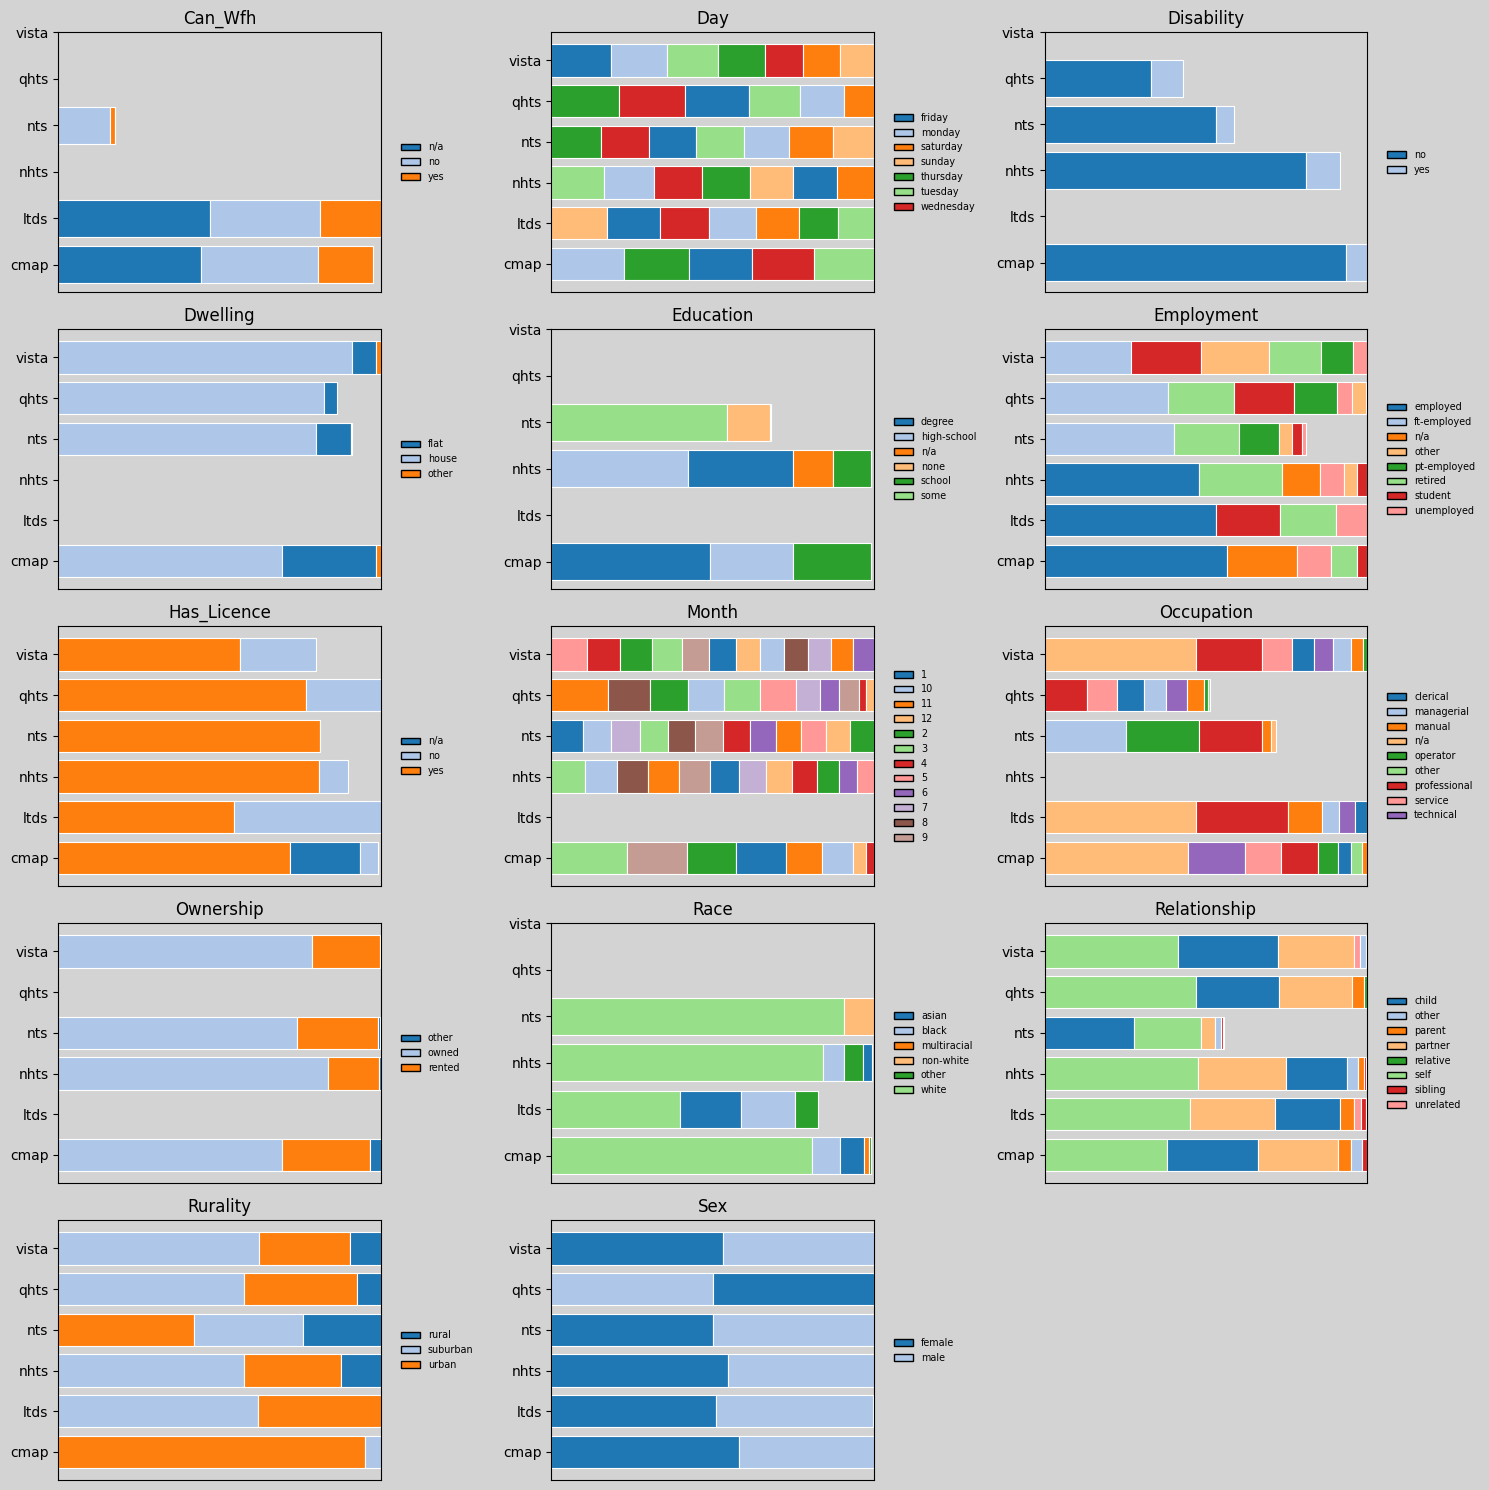

In [81]:
# ---------------------------------------------
# Select categorical columns (excluding id/meta)
# ---------------------------------------------
cat_cols = {
    col for col in attributes.columns if attributes[col].dtype == pl.String
} - {"source", "pid", "hid", "country"}

# ---------------------------------------------
# Grid layout
# ---------------------------------------------
n_cols = 3
n_plots = len(cat_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(5 * n_cols, 3.0 * n_rows), squeeze=False
)

# ---------------------------------------------
# Sample once for consistency
# ---------------------------------------------
if attributes.height > 10_000:
    df_plot = attributes.sample(n=10_000, shuffle=True)
else:
    df_plot = attributes


# ---------------------------------------------
# Helper: build consistent color map
# ---------------------------------------------
def build_color_map_for_column(
    df: pl.DataFrame, col: str, cmap_name: str = "tab20"
):
    uniques = df.select(pl.col(col)).drop_nulls().unique().to_series().to_list()

    non_unknown = sorted(v for v in uniques if str(v).lower() != "unknown")

    cmap = plt.get_cmap(cmap_name)
    if hasattr(cmap, "colors") and cmap.colors is not None:
        palette = list(cmap.colors)
    else:
        palette = [cmap(i / 20) for i in range(20)]

    color_cycle = cycle(palette)
    return {v: next(color_cycle) for v in non_unknown}


# ---------------------------------------------
# Plot one column + legend
# ---------------------------------------------
def plot_column(ax, df: pl.DataFrame, col: str, on: str):

    groups = df.select(pl.col(on)).drop_nulls().unique().to_series().to_list()
    groups = sorted(groups)

    color_map = build_color_map_for_column(df, col)

    for i, g in enumerate(groups):
        sub = df.filter(pl.col(on) == g)
        proportions = (
            sub[col]
            .value_counts(normalize=True)
            .sort("proportion", descending=True)
        )

        unknown = proportions.filter(
            pl.col(col).cast(pl.Utf8).str.to_lowercase() == "unknown"
        )
        other = proportions.filter(
            pl.col(col).cast(pl.Utf8).str.to_lowercase() != "unknown"
        )

        proportions = other.vstack(unknown)

        left = 0.0
        for val, prop in proportions.select(col, "proportion").iter_rows():
            if val is None:
                continue

            color = color_map.get(val, "#999999")

            ax.barh(
                y=i,
                width=float(prop),
                left=left,
                color=color,
                edgecolor="white",
                linewidth=0.8,
            )
            left += float(prop)

    ax.set_title(col.title())
    ax.set_yticks(range(len(groups)))
    ax.set_yticklabels(groups)
    ax.set_xticks([])
    ax.set_xlim(0, 1)

    # -----------------------------------------
    # Add legend to the right of the subplot
    # -----------------------------------------
    legend_items = []

    # Non-unknown categories
    for i, (cat, color) in enumerate(color_map.items()):
        label = str(cat)
        label_length = min(12, len(label))
        legend_items.append(
            Patch(
                facecolor=color, edgecolor="black", label=label[:label_length]
            )
        )
        if i >= 13:
            break  # Limit to 13 categories for readability

    ax.legend(
        handles=legend_items,
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        borderaxespad=0.0,
        fontsize="x-small",
        facecolor="none",
        edgecolor="none",
    )

    ax.set_facecolor("lightgray")  # transparent axes background


fig.patch.set_facecolor("lightgray")  # transparent figure background


# ---------------------------------------------
# Render each subplot
# ---------------------------------------------
for idx, col in enumerate(sorted(cat_cols)):
    r = idx // n_cols
    c = idx % n_cols
    ax = axes[r][c]

    plot_column(ax, df_plot, col, on="source")

# Remove empty axes
for i in range(n_plots, n_rows * n_cols):
    r = i // n_cols
    c = i % n_cols
    axes[r][c].axis("off")

plt.tight_layout()
plt.show()